# Tutorial 2: Alignment of developmental axolotl telencephalon data
This tutorial demonstrates the results of SpaTemporal alignment of developmental axolotl telencephalon datasets before and after alignment.

## Preparation

In [1]:
import os
import torch
import time
import subprocess
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

## Load Data

In [2]:
data_root = Path('../Data/ARTISTA/')

# proj_list = [
#      'Stage44', 'Stage54', 'Stage57',
# ]

proj_list = [
    'Stage44', 'Stage54', 'Stage57', 'Juv', 'Adult', 'Meta'
]

In [3]:
for proj_name in tqdm(proj_list):
    adata_tmp = sc.read_h5ad(os.path.join(data_root, proj_name + '.h5ad'))
    adata_tmp.var_names_make_unique()

    adata_tmp.obs['timepoint'] = proj_name
    #graph_dict_tmp = SEDR.graph_construction(adata_tmp, 12)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    
    if proj_name == proj_list[0]:
        adata = adata_tmp
        #graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['timepoint'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['timepoint'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        #graph_dict = SEDR.combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

100%|██████████| 6/6 [14:47<00:00, 147.85s/it]


## Alignment

In [4]:
def _obtain_tp_loc_info(adata):
    '''
    Obtain the location and time point information from the adata object.
    The location is standardized and concatenated with the time point information.
    The time point information is one-hot encoded.
    '''
    # in case the timepoint is not numeric
    adata.obs['timepoint_numeric'] = adata.obs['timepoint'].astype('category').cat.codes
    tp_info = np.array(adata.obs['timepoint_numeric']).astype('int')
    tp_mat = np.zeros((tp_info.size, tp_info.max()+1))
    tp_mat[np.arange(tp_info.size), tp_info] = 1
    n_tp = tp_mat.shape[1]
    # scale locations per time point
    loc = adata.obsm['spatial']
    loc_scaled = np.zeros(loc.shape, dtype=np.float64)
    for i in range(n_tp):
        scaler = StandardScaler()
        tp_loc = loc[tp_mat[:,i]==1, :]
        tp_loc = scaler.fit_transform(tp_loc)
        loc_scaled[tp_mat[:,i]==1, :] = tp_loc
    loc = loc_scaled
    loc = np.concatenate((loc, tp_mat), axis=1)
    return loc

In [5]:
loc = _obtain_tp_loc_info(adata)

In [7]:
adata.obsm["loc"] = loc

In [14]:
from matplotlib import cm
import matplotlib

def plot_aligned_slices(adata_st_list, coor_key="loc", title="After alignment"):
    # cmap = cm.get_cmap('rainbow', len(adata_st_list))
    # colors_list = [matplotlib.colors.rgb2hex(cmap(i)) for i in range(len(adata_st_list))]
    # colors_list = ['#FF0000', '#00FF00', '#0000FF', "#FD5B5B", "#A6F7A6", "#8D8DFF"]
    colors_list = ['#0000FF', '#00FF00', '#FF0000', "#FD5B5B", "#A6F7A6", "#8D8DFF"]

    plt.figure(figsize=(6, 6))
    plt.title(title)
    for i in range(len(adata.obs["timepoint_numeric"].unique())):
        coords = adata[adata.obs["timepoint_numeric"]==i].obsm[coor_key]
        plt.scatter(coords[:, 0], coords[:, 1], 
                    c=colors_list[i], 
                    label=f"Slice {i}", 
                    s=5., alpha=0.5)
    
    ax = plt.gca()
    ax.set_ylim(ax.get_ylim()[::-1])
    plt.xticks([])
    plt.yticks([])
    #plt.legend(loc=(1.02, 0.2), ncol=(len(adata_st_list)//13 + 1))
    plt.savefig("ordered_2d_slices1.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

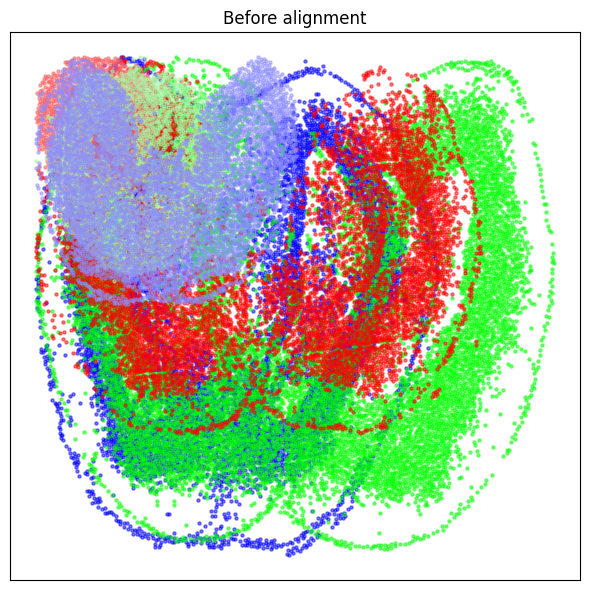

In [15]:
plot_aligned_slices(adata, coor_key="spatial", title="Before alignment")

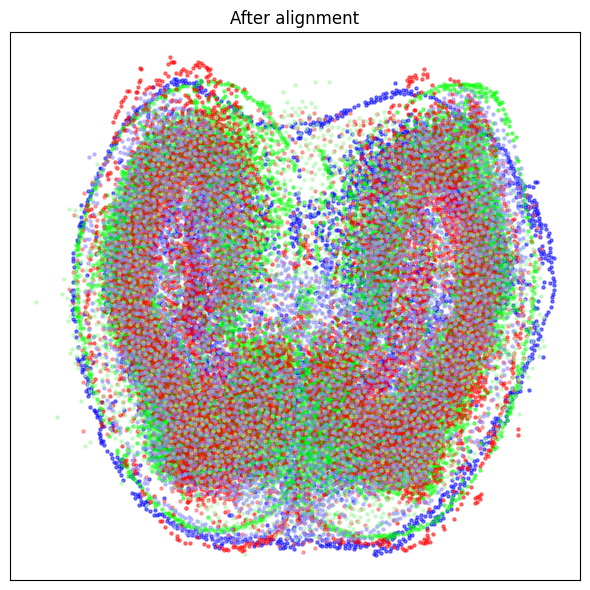

In [16]:
plot_aligned_slices(adata, coor_key="loc", title="After alignment")

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_aligned_slices_3d(adata, coor_key="loc", title="After alignment (3D View)"):
    colors_list = ['#FF0000', '#00FF00', '#0000FF', "#FD5B5B", "#A6F7A6", "#8D8DFF"]
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title(title)

    unique_tp = sorted(adata.obs["timepoint_numeric"].unique())

    for i in unique_tp:
        mask = adata.obs["timepoint_numeric"] == i
        coords = adata.obsm[coor_key][mask]

        x = coords[:, 0]
        y = coords[:, 1]
        z = np.full_like(x, i) 

        ax.scatter(x, y, z, 
                   c=colors_list[i % len(colors_list)], 
                   label=f"Slice {i}", 
                   s=5., alpha=0.6)

    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Timepoint / Slice')

    ax.invert_yaxis() 

    ax.view_init(elev=20, azim=30) 

    plt.legend(loc=(1.05, 0.5))
    plt.tight_layout()
    plt.show()

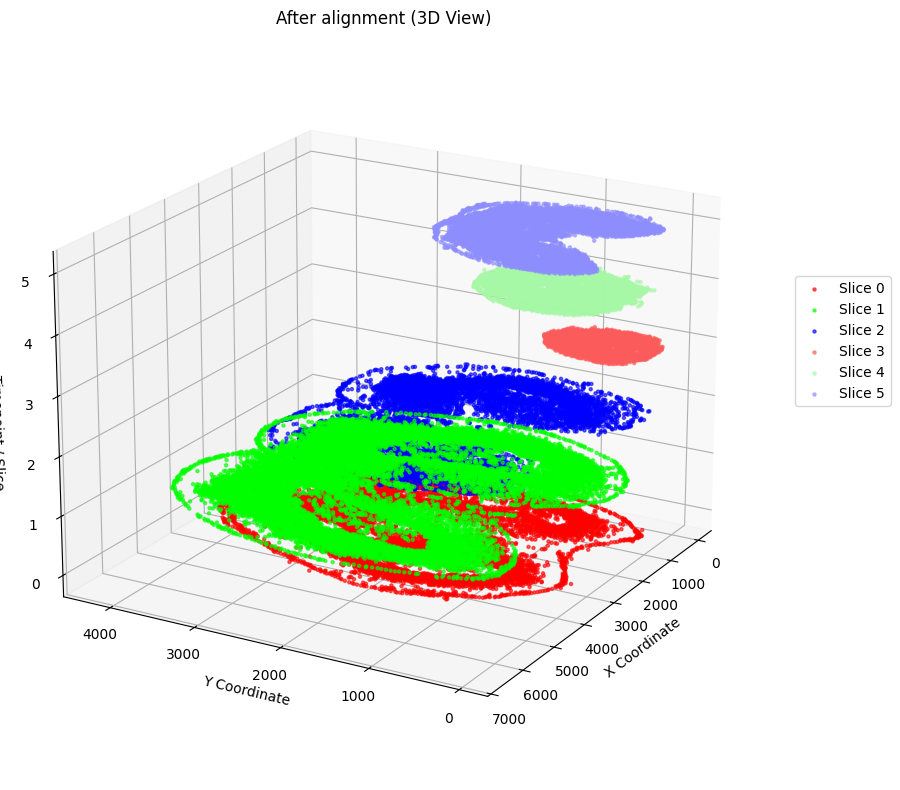

In [ ]:
plot_aligned_slices_3d(adata, coor_key="spatial", title="Before alignment")

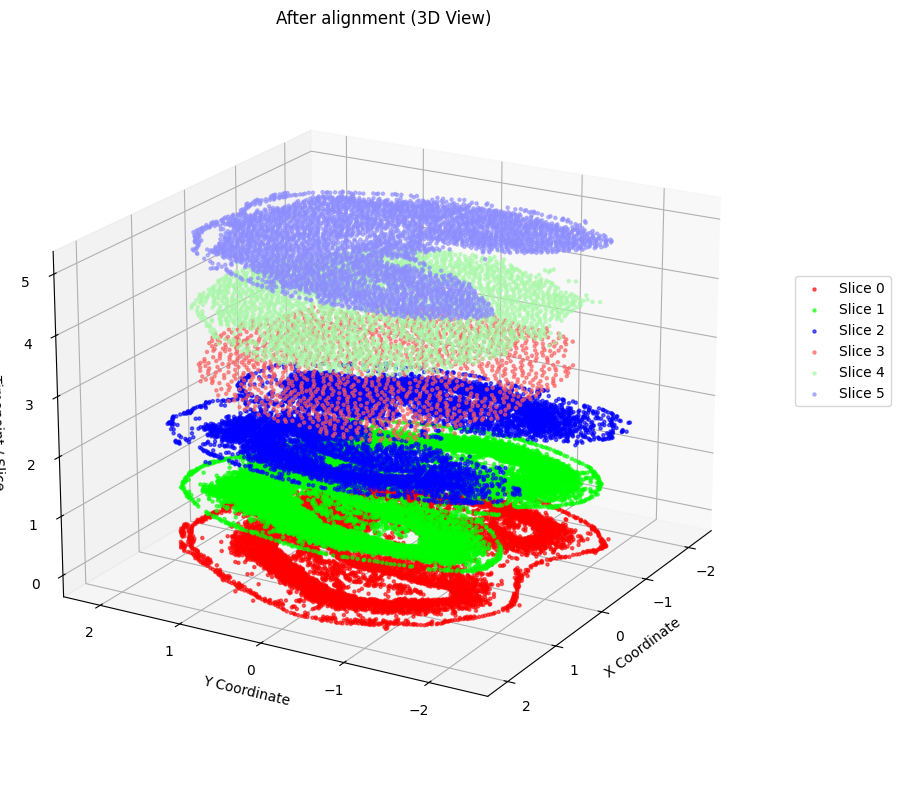

In [ ]:
# 调用函数
plot_aligned_slices_3d(adata, coor_key="loc", title="After alignment")